## **Figure 4**: _Mechanical force percolation within the EVL is dependent on keratin expression_

In [1]:
from src.BinnedPlotter import BinnedIntensityPlotter
from src.CircDusoleiWound import CircularAverageAnalyzer, save_curves_to_csv
from src.CircDusoleiWound import average_timepoint_curves_across_folders as avgFolders
from src.Figureplot import setup_figure
import seaborn as sns
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import re 

Figureplot.py run on  20260306


In [10]:
def process_single_file_with_bins(file_path, angle_offset=0):
    """
    Process angles from a single CSV file and store angles with their bin assignments.
    
    Parameters:
    - file_path: path to CSV file
    - angle_offset: angle offset to add
    """
    angles = pd.read_csv(file_path)["Angle"] + angle_offset
    # Apply transformations
    angles = np.where(angles > 90, 180 - angles, angles)
    angles = np.where(angles < 0, angles + 180, angles)
    
    # Compute histogram
    angle_bins = np.linspace(0, 90, 10)
    hist, bin_edges = np.histogram(angles, bins=angle_bins)
    
    # Assign each angle to a bin
    bin_indices = np.digitize(angles, angle_bins) - 1
    
    return angles, bin_indices, hist, bin_edges, angle_bins

# Load all data
controlfiles = sorted(glob(os.path.join("data/Fig4/4B/", "*Control*.csv")))
mofiles = sorted(glob(os.path.join("data/Fig4/4B/", "*K4K8MO*.csv")))

print(f"Found {len(controlfiles)} control files and {len(mofiles)} morphant files")
print("Control files:", controlfiles)
print("MO files:", mofiles)

# Process all files individually
control_data = [process_single_file_with_bins(f) for f in controlfiles]
mo_data = [process_single_file_with_bins(f) for f in mofiles]

# Compute mean and std histograms for each condition
angle_bins = np.linspace(0, 90, 10)
control_hists = np.array([hist for _, _, hist, _, _ in control_data])
mo_hists = np.array([hist for _, _, hist, _, _ in mo_data])

control_mean_hist = np.mean(control_hists, axis=0)
control_std_hist = np.std(control_hists, axis=0)
mo_mean_hist = np.mean(mo_hists, axis=0)
mo_std_hist = np.std(mo_hists, axis=0)

Found 3 control files and 4 morphant files
Control files: ['data/Fig4/4B/Results_21032023_TgUtrmcherry_Pos001_Control_f33.csv', 'data/Fig4/4B/Results_Pos001_Control_f024.csv', 'data/Fig4/4B/Results_Pos002_Control_f025.csv']
MO files: ['data/Fig4/4B/Results_21032023_TgUtrmcherry_Pos003_K4K8MO-f33.csv', 'data/Fig4/4B/Results_21032023_TgUtrmcherry_Pos004_K4K8MO_f33.csv', 'data/Fig4/4B/Results_Pos003_K4K8MO_f026.csv', 'data/Fig4/4B/Results_Pos004_K4K8MO_f029.csv']


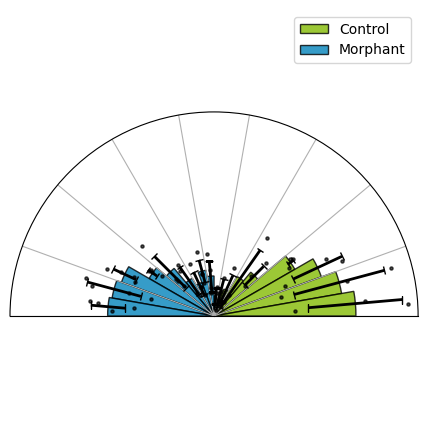

In [11]:
# Create polar plot with mean histograms and scatter points (one per bin per file)
bin_edges_rad = np.deg2rad(angle_bins)
bin_width = bin_edges_rad[1] - bin_edges_rad[0]
bin_centers = (angle_bins[:-1] + angle_bins[1:]) / 2
bin_centers_rad = np.deg2rad(bin_centers)

fig, ax = plt.subplots(figsize=(7, 5.3), subplot_kw={'projection': 'polar'})

# Plot Control - INVERTED (leftmost bin becomes rightmost)
# Invert by subtracting from 90 degrees
control_bins_inverted = 90 - bin_centers
control_bins_inverted_rad = np.deg2rad(control_bins_inverted)

ax.bar(
    control_bins_inverted_rad, control_mean_hist, width=bin_width,
    edgecolor='black', alpha=0.8, linewidth=1, color='#83bb03', 
    label='Control', yerr=control_std_hist, error_kw={'elinewidth': 2, 'capsize': 3}
)

# Plot scatter points - one point per control file per bin (inverted)
for file_idx, (angles, bin_indices, hist, _, _) in enumerate(control_data):
    # For each bin, plot one point representing this file's histogram value
    for bin_idx in range(len(angle_bins) - 1):
        # Use the histogram value (count) for this file in this bin
        radii = hist[bin_idx]
        # Add angular jitter so points don't overlap exactly
        angle_jitter = control_bins_inverted_rad[bin_idx] + np.random.uniform(-bin_width/4, bin_width/4)
        # Add radial jitter for visibility
        radii_jitter = radii + np.random.uniform(-0.3, 0.3)
        ax.scatter(
            angle_jitter, radii_jitter, 
            color='black', edgecolors='black', s=5, alpha=0.7, zorder=2
        )

# Plot MO (offset by 90 degrees / pi/2 radians for visibility)
offset_radians = np.pi / 2
mo_bins_offset_rad = bin_centers_rad + offset_radians

ax.bar(
    mo_bins_offset_rad, mo_mean_hist, width=bin_width,
    edgecolor='black', alpha=0.8, linewidth=1, color='#0383bb', 
    label='Morphant', yerr=mo_std_hist, error_kw={'elinewidth': 2, 'capsize': 3}
)

# Plot scatter points - one point per MO file per bin
for file_idx, (angles, bin_indices, hist, _, _) in enumerate(mo_data):
    # For each bin, plot one point representing this file's histogram value
    for bin_idx in range(len(angle_bins) - 1):
        # Use the histogram value (count) for this file in this bin
        radii = hist[bin_idx]
        # Add angular jitter so points don't overlap exactly
        angle_jitter = mo_bins_offset_rad[bin_idx] + np.random.uniform(-bin_width/4, bin_width/4)
        # Add radial jitter for visibility
        radii_jitter = radii + np.random.uniform(-0.3, 0.3)
        ax.scatter(
            angle_jitter, radii_jitter, 
            color='black', edgecolors='black', s=5, alpha=0.7, zorder=2
        )

# Customize the plot
ax.set_theta_zero_location('E')  # Set 0 degrees to the right (East)
ax.set_theta_direction(1)
ax.set_xticks(np.deg2rad(np.linspace(0, 180, 10)))
ax.set_xticklabels(["" for angle in np.linspace(0, 180, 10)])
ax.set_thetamin(0)  # Set the minimum theta to 0 degrees
ax.set_thetamax(180)  # Set the maximum theta to 180 degrees
ax.set_yticks([])  # Do not show y gridlines
ax.legend(loc='upper right')
outputfolder="Figure/Figure4/4B/"
os.makedirs(outputfolder, exist_ok=True)
plt.savefig(os.path.join(outputfolder, "Woundhealing_PolarPlot.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(outputfolder, "Woundhealing_PolarPlot.pdf"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(outputfolder, "Woundhealing_PolarPlot.svg"), dpi=300, bbox_inches='tight')
plt.show()

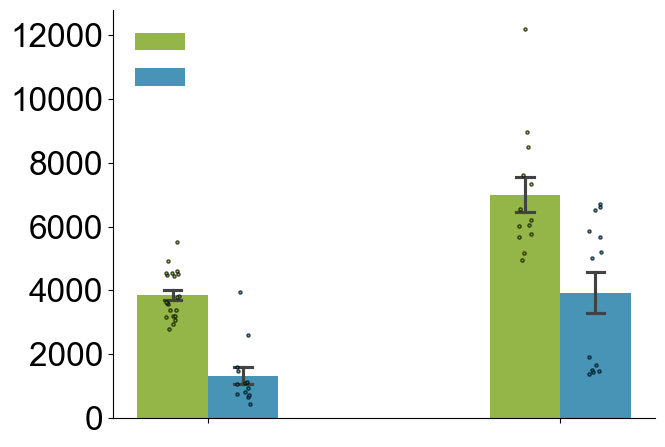

In [4]:
viscositypd=pd.read_csv("data/Fig4/4C/K4K8MOViscosity.csv")
fig,ax=setup_figure()
colorblindpallete=['#009E73','#E69F00','#D55E00','#CC79A7','#F0E442','#56B4E9','#0072B2','#D55E00']
pallete=['#83bb03',"#0383bb"]
ax=sns.barplot(data=viscositypd,x='Stage',y='Eta',palette=pallete,alpha=0.8,hue='Exp Sample',legend=True,width=0.4,errorbar="se", capsize=.1)

# Manually position scatter points to align with bar centers with small jitter
bar_width = 0.4
hue_offset = bar_width / 4  # offset for each hue group
hue_values = sorted(viscositypd['Exp Sample'].unique())

for idx, (stage, group) in enumerate(viscositypd.groupby('Stage')):
    for hue_idx, hue_val in enumerate(hue_values):
        subset = group[group['Exp Sample'] == hue_val]
        if len(subset) > 0:
            x_pos = idx + (hue_idx - 0.5) * bar_width / len(hue_values)
            x_jitter = np.random.uniform(-0.02, 0.02, len(subset))
            ax.scatter(x_pos + x_jitter, subset['Eta'], 
                      edgecolor='black', s=5, alpha=0.7, 
                      color=pallete[hue_idx], zorder=3)

plt.rcParams['font.size'] = 18
#plt.ylabel('Viscosity η (Pa-sec)')
ax.set_xticks(range(2)) # <--- set the ticks first
ax.set_xticklabels(['',''])
output_path="Figure/Figure4/4C/"
os.makedirs(output_path, exist_ok=True)
plt.xlabel('')
plt.ylabel('')
sns.despine()
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles,loc='upper left',frameon=False,fontsize=18,labels=[' ','  '])
plt.savefig(os.path.join(output_path, "Viscosity_BarPlot.png"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(output_path, "Viscosity_BarPlot.pdf"), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(output_path, "Viscosity_BarPlot.svg"), dpi=300, bbox_inches='tight')
plt.show()  

In [2]:
cfolder=glob("data/Fig4/4E/Control*/*/PIV/ASCII/")
timepoint_indices = [1,3,6]

dist_common, mean_curves, sem_curves, per_folder_curves = avgFolders(
    folders=cfolder,
    timepoint_indices=timepoint_indices,
    num_ranges=10,
    folderdepth=20,
    binning='absolute',
    common_max_radius=150
)


Analyzing 20 files in data/Fig4/4E/Control2/TimeSrs0004/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Control2/TimeSrs0006/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Control2/TimeSrs0000/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Control2/TimeSrs0002/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Control2/TimeSrs024025/PIV/ASCII/


...

Analyzing 20 files in data/Fig4/4E/Control2/TimeSrs0008/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Control1/TimeSrs02324/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Control1/TimeSrs025/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Control1/TimeSrs02021/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Control1/TimeSrs022/PIV/ASCII/


In [3]:
from src.CircDusoleiWound import save_curves_to_csv

# Save control curves
save_curves_to_csv(
    distances_common=dist_common,
    per_folder_curves=per_folder_curves,
    folders=cfolder,
    output_dir="Figure/Figure4/4E/Control",
    condition_name="Control"
)

Saved curves to: Figure/Figure4/4E/Control/Control_curves.csv


,distance,ASCII_TimePoint_1,ASCII_TimePoint_3,ASCII_TimePoint_6
0,0.000000,0.091443,0.093860,0.050624
1,16.666667,0.188716,0.114680,0.059469
2,33.333333,0.304902,0.125951,0.053768
3,50.000000,0.382442,0.113047,0.046366
4,66.666667,0.414068,0.094209,0.041494
5,83.333333,0.428790,0.074272,0.037743
6,100.000000,0.445911,0.061732,0.035969
7,116.666667,0.456630,0.055618,0.034148
8,133.333333,0.492914,0.045394,0.030139


In [5]:
mfolder=glob("data/Fig4/4E/Morphant*/*/PIV/ASCII/")
timepoint_indices = [1,3,6]

moDist_common, mo_mean_curves, mo_sem_mo_curves, mo_per_folder_curves = avgFolders(
    folders=mfolder,
    timepoint_indices=timepoint_indices,
    num_ranges=10,
    folderdepth=20,
    binning='absolute',
    common_max_radius=150
)
save_curves_to_csv(
    distances_common=moDist_common,
    per_folder_curves=mo_per_folder_curves,
    folders=mfolder,
    output_dir="Figure/Figure4/4E/Morphant",
    condition_name="Morphant"
)


Analyzing 20 files in data/Fig4/4E/Morphant2/TimeSrs0004/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Morphant2/TimeSrs0011/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Morphant2/TimeSrs0002/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Morphant2/TimeSrs0012/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Morphant2/TimeSrs0016/PIV/ASCII/


...

Analyzing 20 files in data/Fig4/4E/Morphant1/TimeSrs013/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Morphant1/TimeSrs001/PIV/ASCII/


Analyzing 20 files in data/Fig4/4E/Morphant1/TimeSrs000/PIV/ASCII/


Saved curves to: Figure/Figure4/4E/Morphant/Morphant_curves.csv


,distance,TimeSrs0004_TimePoint_1,TimeSrs0011_TimePoint_1,TimeSrs0002_TimePoint_1,TimeSrs0012_TimePoint_1,TimeSrs0016_TimePoint_1,TimeSrs0018_TimePoint_1,TimeSrs0015_TimePoint_1,TimeSrs006_TimePoint_1,TimeSrs004_TimePoint_1,...,TimeSrs0012_TimePoint_6,TimeSrs0016_TimePoint_6,TimeSrs0018_TimePoint_6,TimeSrs0015_TimePoint_6,TimeSrs006_TimePoint_6,TimeSrs004_TimePoint_6,TimeSrs010_TimePoint_6,TimeSrs013_TimePoint_6,TimeSrs001_TimePoint_6,TimeSrs000_TimePoint_6
0,0.000000,0.099116,0.026838,0.108838,0.051909,0.017694,0.127050,0.013472,0.010375,0.051297,...,0.104109,0.079512,0.050604,0.017665,0.007626,0.030337,0.031953,0.013931,0.039777,0.032210
1,16.666667,0.137653,0.100182,0.122921,0.115386,0.050858,0.144366,0.029540,0.019323,0.117579,...,0.091252,0.103550,0.074760,0.020254,0.013100,0.061259,0.029868,0.017510,0.048842,0.028598
2,33.333333,0.164913,0.141523,0.167102,0.153956,0.064121,0.168437,0.037068,0.018415,0.143774,...,0.075114,0.124842,0.087256,0.019544,0.015281,0.076062,0.029855,0.017904,0.040169,0.030882
3,50.000000,0.167154,0.143849,0.185197,0.229941,0.045412,0.236652,0.030749,0.019750,0.147229,...,0.057480,0.114176,0.088313,0.018462,0.020388,0.069261,0.028938,0.016507,0.033179,0.029909
4,66.666667,0.149871,0.123772,0.184506,0.299599,0.035708,0.288733,0.026755,0.017972,0.127034,...,0.048701,0.084487,0.078983,0.017333,0.015075,0.058148,0.027009,0.014743,0.026533,0.026928
5,83.333333,0.130045,0.109425,0.158037,0.345028,0.037848,0.324331,0.019794,0.015314,0.094913,...,0.043259,0.060996,0.065437,0.013076,0.014694,0.045282,0.025469,0.013309,0.021769,0.025271
6,100.000000,0.128097,0.128598,0.099847,0.267034,0.040775,0.326634,0.017021,0.015597,0.064233,...,0.043205,0.046555,0.054997,0.009733,0.015925,0.025812,0.025008,0.012538,0.018282,0.025397
7,116.666667,0.151564,0.113412,0.059179,0.241387,0.048910,0.327890,0.016068,0.013480,0.036336,...,0.035229,0.030310,0.045443,0.007823,0.013685,0.006245,0.020331,0.012752,0.018375,0.024024
8,133.333333,0.146998,0.129953,0.059179,0.269803,0.043500,0.349089,0.011076,0.008393,0.019778,...,0.027501,0.018502,0.028028,0.007015,0.009893,0.003138,0.019698,0.013543,0.021802,0.019900
